# Credit Risk Analytics — Nova Bank
---
## Project Overview

This notebook performs end-to-end data analysis on loan application data from **Nova Bank**, a financial institution providing personal, medical, education, and business loans across the **USA, UK, and Canada**.

**Objective:** Support fair, data-driven lending policies by uncovering patterns in borrower behaviour and default risk.

**Workflow:**
1. Environment Setup
2. Load & Inspect Data
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis (EDA)
6. Save Cleaned Dataset

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn

**Source:** DataDNA September Challenge — [challenge brief](https://datadna.onyxdata.co.uk/challenges/september-2025-datadna-credit-risk-analytics-challenge/)


---
## 1. Environment Setup

In [26]:
# === Core Libraries ===
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# === Visualisation ===
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from itertools import combinations

# === Display Settings ===
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.3f}'.format)
pd.set_option('display.width', 120)

# === Plot Style ===
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.figsize':    (12, 5),
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'figure.dpi':        100,
})

# === Colour Palette (consistent throughout notebook) ===
PALETTE = {
    'primary':   '#2166ac',
    'danger':    '#d73027',
    'safe':      '#1a9850',
    'warning':   '#f46d43',
    'neutral':   '#969696',
    'highlight': '#fdae61',
}

GRADE_COLORS = {
    'A': '#1a9850', 'B': '#91cf60', 'C': '#fee08b',
    'D': '#fc8d59', 'E': '#d73027', 'F': '#a50026', 'G': '#67001f'
}

print(" Environment ready")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")

 Environment ready
   pandas  2.2.2
   numpy   2.0.2


---
## 2. Load & Inspect Data

In [27]:
# === Load Raw Dataset ===
raw = pd.read_excel('credit_risk.xlsx')
df  = raw.copy()   # df is the working copy — raw is preserved unchanged

print(f"{'='*50}")
print(f"  Raw dataset loaded")
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print(f"{'='*50}")

df.head(5)

  Raw dataset loaded
  Rows    : 32,581
  Columns : 29


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,gender,marital_status,education_level,country,state,city,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.000,PERSONAL,D,35000,16.020,1,0.590,Y,3,Male,Married,High School,Canada,Ontario,Toronto,43.653,-79.383,Self-employed,36,0.593,"8,402.454",0.736,14,0.496,0
1,CUST_00002,21,9600,OWN,5.000,EDUCATION,B,1000,11.140,0,0.100,N,2,Female,Divorced,Master,Canada,Ontario,Toronto,43.653,-79.383,Full-time,36,0.104,"1,607.803",0.272,10,0.585,3
2,CUST_00003,25,9600,MORTGAGE,1.000,MEDICAL,C,5500,12.870,1,0.570,N,3,Female,Married,Master,UK,Wales,Swansea,51.621,-3.944,Full-time,36,0.573,"2,760.506",0.860,14,0.751,0
3,CUST_00004,23,65500,RENT,4.000,MEDICAL,C,35000,15.230,1,0.530,N,2,Male,Married,Bachelor,Canada,BC,Vancouver,49.283,-123.121,Part-time,12,0.534,"7,155.286",0.644,15,0.379,0
4,CUST_00005,24,54400,RENT,8.000,MEDICAL,C,35000,14.270,1,0.550,Y,4,Female,Single,Bachelor,USA,New York,Buffalo,42.886,-78.878,Part-time,36,0.643,"15,626.153",0.931,4,0.228,0


In [28]:
# === Column Overview — dtypes, nulls, unique values ===
quality = pd.DataFrame({
    'dtype':   df.dtypes,
    'nulls':   df.isnull().sum(),
    'null_%':  (df.isnull().sum() / len(df) * 100).round(2),
    'unique':  df.nunique(),
    'sample':  [df[c].dropna().iloc[0] if len(df[c].dropna()) > 0 else 'N/A' for c in df.columns]
})
print("COLUMN OVERVIEW")
print(quality.to_string())

COLUMN OVERVIEW
                              dtype  nulls  null_%  unique         sample
client_ID                    object      0   0.000   32581     CUST_00001
person_age                    int64      0   0.000      58             22
person_income                 int64      0   0.000    4295          59000
person_home_ownership        object      0   0.000       4           RENT
person_emp_length           float64    895   2.750      36        123.000
loan_intent                  object      0   0.000       6       PERSONAL
loan_grade                   object      0   0.000       7              D
loan_amnt                     int64      0   0.000     753          35000
loan_int_rate               float64   3116   9.560     348         16.020
loan_status                   int64      0   0.000       2              1
loan_percent_income         float64      0   0.000      77          0.590
cb_person_default_on_file    object      0   0.000       2              Y
cb_person_cred_hist_le

TARGET VARIABLE — loan_status
  Repaid    :  25,473  (78.2%)
  Defaulted :   7,108  (21.8%)
  Total     :  32,581


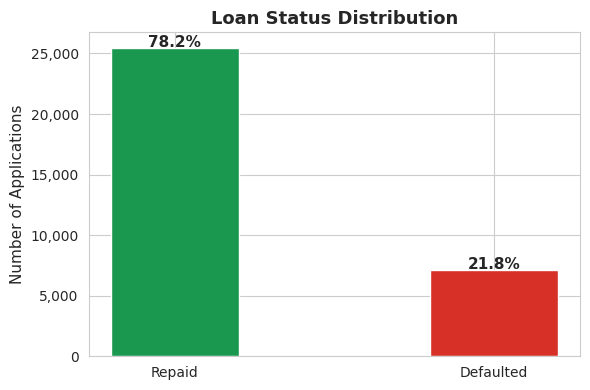

In [29]:
# === Target Variable Distribution ===
target_dist = df['loan_status'].value_counts().rename({0: 'Repaid', 1: 'Defaulted'})
target_pct  = df['loan_status'].value_counts(normalize=True).mul(100).round(1).rename({0: 'Repaid', 1: 'Defaulted'})

print("TARGET VARIABLE — loan_status")
print(f"  Repaid    : {target_dist['Repaid']:>7,}  ({target_pct['Repaid']}%)")
print(f"  Defaulted : {target_dist['Defaulted']:>7,}  ({target_pct['Defaulted']}%)")
print(f"  Total     : {len(df):>7,}")

# Visualise
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(['Repaid', 'Defaulted'],
              [target_dist['Repaid'], target_dist['Defaulted']],
              color=[PALETTE['safe'], PALETTE['danger']], edgecolor='white', width=0.4)
for bar, pct in zip(bars, [target_pct['Repaid'], target_pct['Defaulted']]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{pct}%', ha='center', fontweight='bold', fontsize=11)
ax.set_title('Loan Status Distribution')
ax.set_ylabel('Number of Applications')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

---
## 3. Data Cleaning

### 3.1 Missing Values Overview

In [30]:
# === Identify Missing Values ===
missing = (df.isnull().sum()
             .pipe(lambda s: s[s > 0])
             .to_frame('null_count')
             .assign(null_pct=lambda x: (x['null_count'] / len(df) * 100).round(2)))

print("MISSING VALUES SUMMARY")
print(missing.to_string())
print(f"\n {df.shape[1] - len(missing)} of {df.shape[1]} columns are complete")
print(f" {len(missing)} columns require treatment")

MISSING VALUES SUMMARY
                   null_count  null_pct
person_emp_length         895     2.750
loan_int_rate            3116     9.560

 27 of 29 columns are complete
 2 columns require treatment


### 3.2 Employment Length & Interest Rate

**Strategy:**
- `person_emp_length`: values above 60 years are biologically implausible — replace with NaN then impute with median
- `loan_int_rate`: impute missing values using the median rate per loan grade, preserving the relationship between grade and rate

In [31]:
# --- Inspect before cleaning ---
print("BEFORE CLEANING")
print(df[['person_emp_length', 'loan_int_rate']].describe().round(2))

# --- Employment length: cap at 60 years, impute with median ---
reasonable_max_emp = 60
df['person_emp_length'] = df['person_emp_length'].where(df['person_emp_length'] <= reasonable_max_emp)

median_emp = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(median_emp)
print(f"\n  Median used for emp_length imputation : {median_emp} years")

# --- Interest rate: impute with median per loan grade ---
median_rate_by_grade = df.groupby('loan_grade')['loan_int_rate'].transform('median')
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_rate_by_grade)

# --- Verify ---
print("\nMISSING VALUES AFTER TREATMENT")
print(df[['person_emp_length', 'loan_int_rate']].isnull().sum())
print("\nAFTER CLEANING")
print(df[['person_emp_length', 'loan_int_rate']].describe().round(2))

BEFORE CLEANING
       person_emp_length  loan_int_rate
count         31,686.000     29,465.000
mean               4.790         11.010
std                4.140          3.240
min                0.000          5.420
25%                2.000          7.900
50%                4.000         10.990
75%                7.000         13.470
max              123.000         23.220

  Median used for emp_length imputation : 4.0 years

MISSING VALUES AFTER TREATMENT
person_emp_length    0
loan_int_rate        0
dtype: int64

AFTER CLEANING
       person_emp_length  loan_int_rate
count         32,581.000     32,581.000
mean               4.760         11.010
std                3.980          3.210
min                0.000          5.420
25%                2.000          7.880
50%                4.000         10.990
75%                7.000         13.480
max               41.000         23.220


### 3.3 Age Outliers

**Strategy:** Ages above 100 are biologically implausible given the dataset's context. Replace with NaN and impute using the dataset median.

In [32]:
# --- Inspect before cleaning ---
print("BEFORE CLEANING — person_age")
print(df['person_age'].describe().round(2))

# --- Identify and replace impossible ages ---
impossible_limit = 100
impossible_mask  = df['person_age'] > impossible_limit
num_impossible   = impossible_mask.sum()
print(f"\n  Records with age > {impossible_limit} : {num_impossible}")

df['person_age'] = df['person_age'].where(~impossible_mask)

# --- Impute with median ---
median_age = df['person_age'].median()
df['person_age'] = df['person_age'].fillna(median_age)
print(f"  Median used for age imputation      : {median_age} years")

# --- Verify ---
print("\nAFTER CLEANING — person_age")
print(df['person_age'].describe().round(2))

BEFORE CLEANING — person_age
count   32,581.000
mean        27.730
std          6.350
min         20.000
25%         23.000
50%         26.000
75%         30.000
max        144.000
Name: person_age, dtype: float64

  Records with age > 100 : 5
  Median used for age imputation      : 26.0 years

AFTER CLEANING — person_age
count   32,581.000
mean        27.720
std          6.200
min         20.000
25%         23.000
50%         26.000
75%         30.000
max         94.000
Name: person_age, dtype: float64


### 3.4 Post-Cleaning Validation

Confirm that all missing values have been resolved and all data types are correct before feature engineering begins.

In [33]:
# === POST-CLEANING VALIDATION ===
remaining_nulls = df.isnull().sum().sum()
print(f"{'='*50}")
print(f"  POST-CLEANING SUMMARY")
print(f"{'='*50}")
print(f"  Rows              : {df.shape[0]:,}")
print(f"  Columns           : {df.shape[1]}")
print(f"  Total null values : {remaining_nulls}")

if remaining_nulls == 0:
    print("  ✅ No missing values remaining")
else:
    print("  ⚠️  Missing values still present:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

print(f"{'='*50}")
print("\nDTYPES")
print(df.dtypes.to_string())

  POST-CLEANING SUMMARY
  Rows              : 32,581
  Columns           : 29
  Total null values : 0
  ✅ No missing values remaining

DTYPES
client_ID                      object
person_age                    float64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
gender                         object
marital_status                 object
education_level                object
country                        object
state                          object
city                           object
city_latitude                 float64
city_longitude                float64
employment_type                object
loan_term_months      

---
## 4. Feature Engineering

Four new features are engineered to support segmented analysis in both Python EDA and the Power BI dashboard.

### 4.1 Age Grouping

Bin continuous age into meaningful demographic segments for analysis.

In [34]:
# === AGE GROUP & AGE CLASS ===
age_bins   = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

df['age_group'] = pd.cut(df['person_age'], bins=age_bins, labels=age_labels, right=False)

age_class_map = {
    '18-24': 'Youth',       '25-34': 'Young Adult',
    '35-44': 'Adult',       '45-54': 'Middle Age',
    '55-64': 'Senior',      '65+':   'Elderly'
}
df['age_class'] = df['age_group'].map(age_class_map)

print("AGE GROUP DISTRIBUTION")
print(df['age_group'].value_counts().sort_index().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(df)*100).round(1))
      .to_string())

AGE GROUP DISTRIBUTION
           count    pct
age_group              
18-24      12315 37.800
25-34      16185 49.700
35-44       3326 10.200
45-54        601  1.800
55-64        115  0.400
65+           39  0.100


### 4.2 Employment Tenure Grouping

Bin employment length into career-stage segments to analyse stability and default risk.

In [35]:
# === EMPLOYMENT TENURE GROUP ===
bins_emp   = [-1, 2, 5, 10, 15, 19, 100]
labels_emp = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-15 yrs', '16-19 yrs', '20+ yrs']

df['emp_tenure_group'] = pd.cut(df['person_emp_length'], bins=bins_emp, labels=labels_emp)

print("EMPLOYMENT TENURE GROUP DISTRIBUTION")
print(df['emp_tenure_group'].value_counts().sort_index().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(df)*100).round(1))
      .to_string())

EMPLOYMENT TENURE GROUP DISTRIBUTION
                  count    pct
emp_tenure_group              
0-2 yrs           10869 33.400
3-5 yrs           10173 31.200
6-10 yrs           8612 26.400
11-15 yrs          2314  7.100
16-19 yrs           462  1.400
20+ yrs             151  0.500


### 4.3 Loan Cost, Amount Bands & Default Label

In [36]:
# === TOTAL LOAN COST ===
# Estimated full repayment amount including interest over the loan term
df['total_loan_cost'] = df['loan_amnt'] * (
    1 + (df['loan_int_rate'] / 100) * (df['loan_term_months'] / 12)
)

# === LOAN AMOUNT BANDS ===
df['loan_amnt_band'] = pd.cut(df['loan_amnt'],
    bins=[0, 4000, 8000, 12000, 16000, 20000, 26000, 100000],
    labels=['$0-4k', '$4-8k', '$8-12k', '$12-16k', '$16-20k', '$20-26k', '$26k+'])

# === DEFAULT LABEL ===
df['default_label'] = df['loan_status'].map({0: 'Non-Default', 1: 'Default'})

print("LOAN AMOUNT BAND DISTRIBUTION")
print(df['loan_amnt_band'].value_counts().sort_index().to_frame('count')
      .assign(pct=lambda x: (x['count']/len(df)*100).round(1))
      .to_string())

print(f"\nTOTAL LOAN COST — sample stats")
print(df['total_loan_cost'].describe().round(2))

LOAN AMOUNT BAND DISTRIBUTION
                count    pct
loan_amnt_band              
$0-4k            6194 19.000
$4-8k           10611 32.600
$8-12k           7606 23.300
$12-16k          3875 11.900
$16-20k          2155  6.600
$20-26k          1712  5.300
$26k+             428  1.300

TOTAL LOAN COST — sample stats
count   32,581.000
mean    13,075.150
std      9,140.870
min        646.400
25%      6,481.560
50%     10,877.600
75%     17,097.000
max     70,192.500
Name: total_loan_cost, dtype: float64


In [37]:
# === FEATURE ENGINEERING SUMMARY ===
new_cols = ['age_group', 'age_class', 'emp_tenure_group',
            'total_loan_cost', 'loan_amnt_band', 'default_label']

print("FEATURE ENGINEERING SUMMARY")
print(f"  New columns added  : {len(new_cols)}")
print(f"  Final dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("  New columns:")
for col in new_cols:
    dtype = str(df[col].dtype)
    nuniq = df[col].nunique()
    sample = df[col].dropna().iloc[0]
    print(f"    {col:<22} | dtype: {dtype:<12} | unique: {nuniq:<5} | sample: {sample}")

FEATURE ENGINEERING SUMMARY
  New columns added  : 6
  Final dataset shape: 32,581 rows x 35 columns

  New columns:
    age_group              | dtype: category     | unique: 6     | sample: 18-24
    age_class              | dtype: category     | unique: 6     | sample: Youth
    emp_tenure_group       | dtype: category     | unique: 6     | sample: 3-5 yrs
    total_loan_cost        | dtype: float64      | unique: 16767 | sample: 51821.0
    loan_amnt_band         | dtype: category     | unique: 7     | sample: $26k+
    default_label          | dtype: object       | unique: 2     | sample: Default


---
## 5. Exploratory Data Analysis

All findings in this section are computed directly from the cleaned dataset. Each subsection maps to a specific finding in the project README — every number is fully reproducible.

### 5.1 Portfolio Overview

In [38]:
# === PORTFOLIO KPIs ===
total_apps     = len(df)
total_loan_vol = df['loan_amnt'].sum()
avg_loan       = df['loan_amnt'].mean()
avg_int        = df['loan_int_rate'].mean()
default_rate   = df['loan_status'].mean() * 100
total_defaults = df['loan_status'].sum()
avg_lti        = df['loan_to_income_ratio'].mean()
avg_dti        = df['debt_to_income_ratio'].mean()

print(f"{'='*55}")
print(f"  NOVA BANK — PORTFOLIO OVERVIEW")
print(f"{'='*55}")
print(f"  Total Applications   : {total_apps:>12,}")
print(f"  Total Loan Volume    : ${total_loan_vol:>14,.0f}")
print(f"  Average Loan Amount  : ${avg_loan:>14,.0f}")
print(f"  Average Interest Rate: {avg_int:>13.1f}%")
print(f"  Overall Default Rate : {default_rate:>13.1f}%")
print(f"  Total Defaults       : {total_defaults:>12,}")
print(f"  Loans Repaid         : {total_apps - total_defaults:>12,}")
print(f"  Avg Loan-to-Income   : {avg_lti:>13.2f}")
print(f"  Avg Debt-to-Income   : {avg_dti:>13.2f}")
print(f"{'='*55}")

  NOVA BANK — PORTFOLIO OVERVIEW
  Total Applications   :       32,581
  Total Loan Volume    : $   312,431,300
  Average Loan Amount  : $         9,589
  Average Interest Rate:          11.0%
  Overall Default Rate :          21.8%
  Total Defaults       :        7,108
  Loans Repaid         :       25,473
  Avg Loan-to-Income   :          0.17
  Avg Debt-to-Income   :          0.35


### 5.2 Loan Intent & Repayment Behaviour

**Question:** Do certain loan purposes carry more default risk?

LOAN INTENT — DEFAULT & REPAYMENT RATES
      loan_intent  Total_Applications  Total_Defaults  Default_Rate_pct  Repayment_Rate_pct
DEBTCONSOLIDATION                5212            1490            28.600              71.400
          MEDICAL                6071            1621            26.700              73.300
  HOMEIMPROVEMENT                3605             941            26.100              73.900
         PERSONAL                5521            1098            19.900              80.100
        EDUCATION                6453            1111            17.200              82.800
          VENTURE                5719             847            14.800              85.200


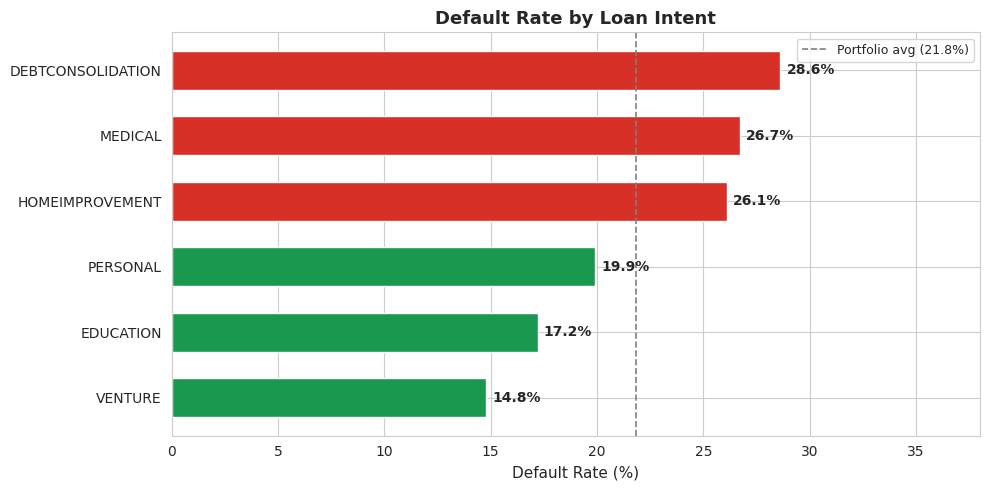

In [39]:
# === LOAN INTENT vs DEFAULT RATE ===
intent_eda = (
    df.groupby('loan_intent')
    .agg(Total_Applications=('loan_status','count'), Total_Defaults=('loan_status','sum'))
    .assign(
        Default_Rate_pct=lambda x: (x['Total_Defaults']/x['Total_Applications']*100).round(1),
        Repayment_Rate_pct=lambda x: (100 - x['Total_Defaults']/x['Total_Applications']*100).round(1)
    )
    .sort_values('Default_Rate_pct', ascending=False)
    .reset_index()
)
print("LOAN INTENT — DEFAULT & REPAYMENT RATES")
print(intent_eda.to_string(index=False))

# Visualisation
fig, ax = plt.subplots(figsize=(10, 5))
colors = [PALETTE['danger'] if r > df['loan_status'].mean()*100 else PALETTE['safe']
          for r in intent_eda['Default_Rate_pct']]
bars = ax.barh(intent_eda['loan_intent'], intent_eda['Default_Rate_pct'],
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, intent_eda['Default_Rate_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.axvline(x=df['loan_status'].mean()*100, color='gray', linestyle='--', linewidth=1.2,
           label=f"Portfolio avg ({df['loan_status'].mean()*100:.1f}%)")
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Loan Intent')
ax.legend(fontsize=9)
ax.set_xlim(0, 38)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.3 Regional Risk Distribution

**Question:** Are there meaningful differences in default risk across countries and cities?

COUNTRY-LEVEL RISK DISTRIBUTION
country  Applications  Defaults  Loan_Volume_USD  Avg_Loan_USD  Default_Rate_pct
 Canada         10785      2358        103986650     9,642.000            21.900
     UK         10944      2378        104778350     9,574.000            21.700
    USA         10852      2372        103666300     9,553.000            21.900

CITY-LEVEL DEFAULT RATES (Top 10)
country          city  Applications  Defaults  Default_Rate_pct
 Canada     Vancouver          1827       442            24.200
    USA        Dallas          1797       424            23.600
     UK     Edinburgh          1807       424            23.500
    USA   Los Angeles          1838       420            22.900
     UK    Manchester          1803       406            22.500
 Canada       Toronto          1751       385            22.000
 Canada      Montreal          1799       394            21.900
 Canada        Ottawa          1802       393            21.800
    USA San Francisco          18

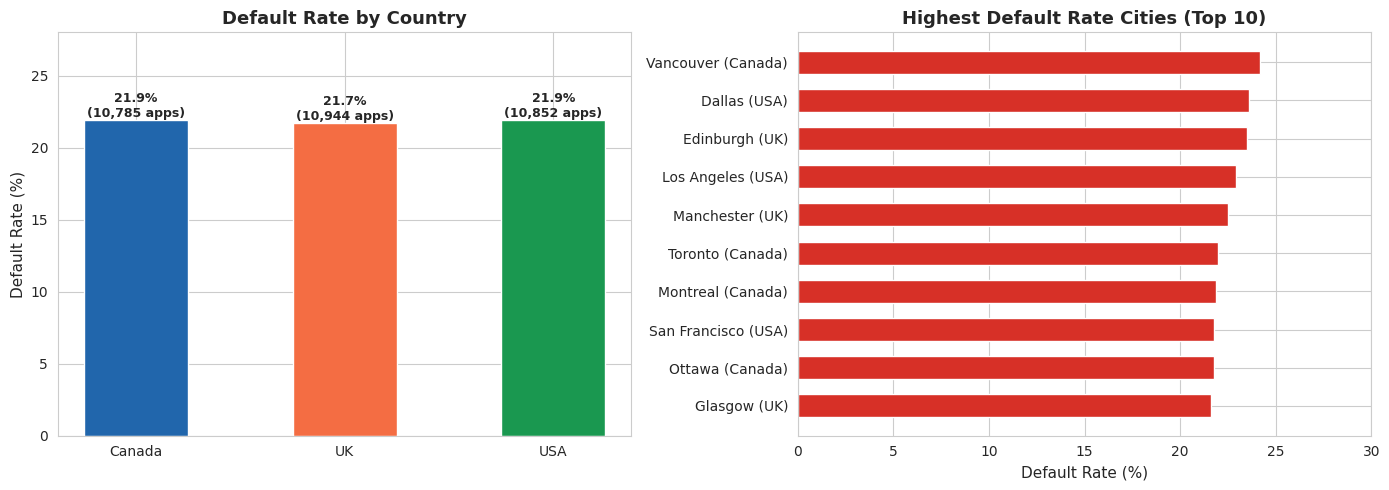

In [40]:
# === COUNTRY LEVEL ===
country_eda = (
    df.groupby('country')
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'),
         Loan_Volume_USD=('loan_amnt','sum'), Avg_Loan_USD=('loan_amnt','mean'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1),
            Avg_Loan_USD=lambda x: x['Avg_Loan_USD'].round(0))
    .reset_index()
)
print("COUNTRY-LEVEL RISK DISTRIBUTION")
print(country_eda.to_string(index=False))

# === CITY LEVEL ===
print()
city_eda = (
    df.groupby(['country','city'])
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .sort_values('Default_Rate_pct', ascending=False)
    .reset_index()
)
print("CITY-LEVEL DEFAULT RATES (Top 10)")
print(city_eda.head(10).to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

country_colors = [PALETTE['primary'], PALETTE['warning'], PALETTE['safe']]
axes[0].bar(country_eda['country'], country_eda['Default_Rate_pct'],
            color=country_colors, edgecolor='white', width=0.5)
for i, (rate, apps) in enumerate(zip(country_eda['Default_Rate_pct'], country_eda['Applications'])):
    axes[0].text(i, rate + 0.2, f'{rate}%\n({apps:,} apps)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0, 28)
axes[0].set_title('Default Rate by Country')
axes[0].set_ylabel('Default Rate (%)')

city_plot = city_eda.sort_values('Default_Rate_pct', ascending=True).tail(10)
axes[1].barh(city_plot['city'] + ' (' + city_plot['country'] + ')',
             city_plot['Default_Rate_pct'],
             color=PALETTE['danger'], edgecolor='white', height=0.6)
axes[1].set_xlabel('Default Rate (%)')
axes[1].set_title('Highest Default Rate Cities (Top 10)')
axes[1].set_xlim(0, 30)
plt.tight_layout()
plt.show()

### 5.4 Borrower Demographics

**Question:** Do gender, age group, and marital status predict default risk?

GENDER — DEFAULT RATES
gender  Applications  Defaults  Default_Rate_pct
Female         16210      3545            21.900
  Male         16371      3563            21.800

AGE GROUP — DEFAULT RATES
age_group  Applications  Defaults  Default_Rate_pct
    18-24         12315      2860            23.200
    25-34         16185      3393            21.000
    35-44          3326       684            20.600
    45-54           601       132            22.000
    55-64           115        31            27.000
      65+            39         8            20.500

MARITAL STATUS — DEFAULT RATES
marital_status  Applications  Defaults  Default_Rate_pct
       Married         11393      2502            22.000
      Divorced          3173       692            21.800
        Single         16368      3562            21.800
       Widowed          1647       352            21.400


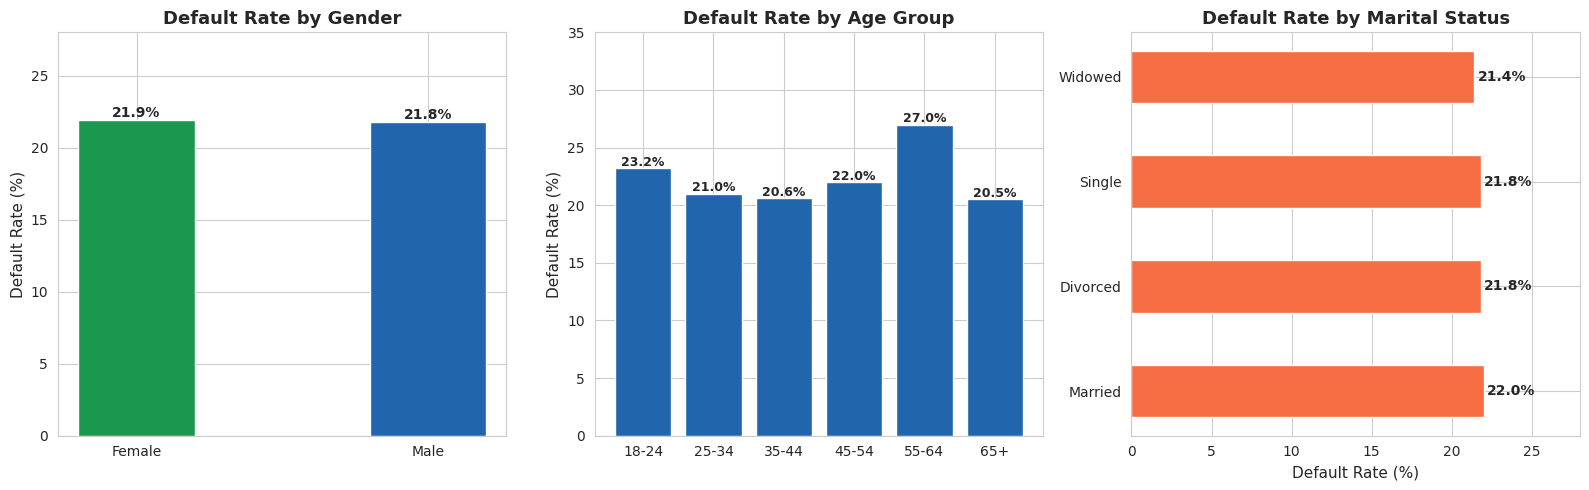

In [41]:
# === GENDER ===
gender_eda = (
    df.groupby('gender')
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("GENDER — DEFAULT RATES")
print(gender_eda.to_string(index=False))

# === AGE GROUP ===
print()
age_eda = (
    df.groupby('age_group', observed=True)
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("AGE GROUP — DEFAULT RATES")
print(age_eda.to_string(index=False))

# === MARITAL STATUS ===
print()
marital_eda = (
    df.groupby('marital_status')
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .sort_values('Default_Rate_pct', ascending=False)
    .reset_index()
)
print("MARITAL STATUS — DEFAULT RATES")
print(marital_eda.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(gender_eda['gender'], gender_eda['Default_Rate_pct'],
            color=[PALETTE['safe'], PALETTE['primary']], edgecolor='white', width=0.4)
for i, v in enumerate(gender_eda['Default_Rate_pct']):
    axes[0].text(i, v + 0.2, f'{v}%', ha='center', fontweight='bold')
axes[0].set_title('Default Rate by Gender')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_ylim(0, 28)

axes[1].bar(age_eda['age_group'].astype(str), age_eda['Default_Rate_pct'],
            color=PALETTE['primary'], edgecolor='white')
for i, v in enumerate(age_eda['Default_Rate_pct']):
    axes[1].text(i, v + 0.2, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Default Rate by Age Group')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, 35)

axes[2].barh(marital_eda['marital_status'], marital_eda['Default_Rate_pct'],
             color=PALETTE['warning'], edgecolor='white', height=0.5)
for bar, v in zip(axes[2].patches, marital_eda['Default_Rate_pct']):
    axes[2].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{v}%', va='center', fontweight='bold')
axes[2].set_title('Default Rate by Marital Status')
axes[2].set_xlabel('Default Rate (%)')
axes[2].set_xlim(0, 28)
plt.tight_layout()
plt.show()

### 5.5 Employment Tenure & Income

**Question:** Does employment stability reduce default risk?

EMPLOYMENT TENURE — DEFAULT RATE & MEDIAN INCOME
emp_tenure_group  Applications  Defaults  Median_Income  Default_Rate_pct
         0-2 yrs         10869      2940     50,000.000            27.000
         3-5 yrs         10173      2137     53,000.000            21.000
        6-10 yrs          8612      1556     60,000.000            18.100
       11-15 yrs          2314       376     70,000.000            16.200
       16-19 yrs           462        62     70,000.000            13.400
         20+ yrs           151        37     68,608.000            24.500


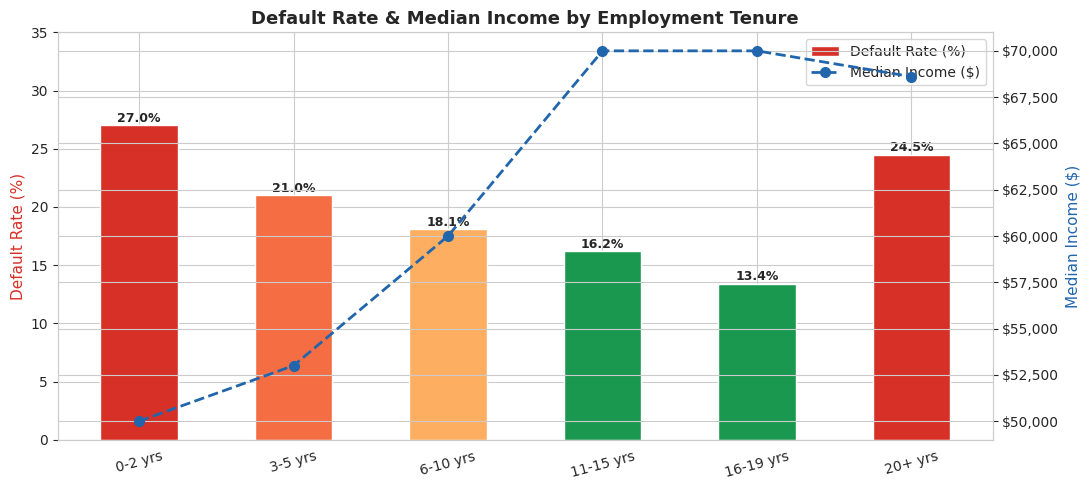

In [42]:
# === EMPLOYMENT TENURE ===
emp_eda = (
    df.groupby('emp_tenure_group', observed=True)
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'),
         Median_Income=('person_income','median'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("EMPLOYMENT TENURE — DEFAULT RATE & MEDIAN INCOME")
print(emp_eda.to_string(index=False))

# Visualisation — dual axis
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()
x = range(len(emp_eda))

bar_colors = [PALETTE['danger'], PALETTE['warning'], PALETTE['highlight'],
              PALETTE['safe'], PALETTE['safe'], PALETTE['danger']]
bars = ax1.bar(x, emp_eda['Default_Rate_pct'], color=bar_colors,
               edgecolor='white', width=0.5, label='Default Rate (%)', zorder=2)
ax2.plot(x, emp_eda['Median_Income'], 'o--', color=PALETTE['primary'],
         linewidth=2, markersize=7, label='Median Income ($)', zorder=3)

for bar, v in zip(bars, emp_eda['Default_Rate_pct']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{v}%', ha='center', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(emp_eda['emp_tenure_group'].astype(str), rotation=15)
ax1.set_ylabel('Default Rate (%)', color=PALETTE['danger'])
ax1.set_ylim(0, 35)
ax2.set_ylabel('Median Income ($)', color=PALETTE['primary'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x):,}'))
ax1.set_title('Default Rate & Median Income by Employment Tenure')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.show()

### 5.6 Credit History & Loan-to-Income Ratio

**Question:** Do credit history length and LTI ratios differ meaningfully across age groups?

CREDIT HISTORY & LTI RATIO BY AGE GROUP
age_group  Avg_Credit_History_Yrs  Avg_LTI_Ratio  Applications  Defaults  Default_Rate_pct
    18-24                   2.990          0.177         12315      2860            23.200
    25-34                   5.970          0.167         16185      3393            21.000
    35-44                  12.730          0.165          3326       684            20.600
    45-54                  15.960          0.163           601       132            22.000
    55-64                  23.820          0.154           115        31            27.000
      65+                  24.540          0.194            39         8            20.500


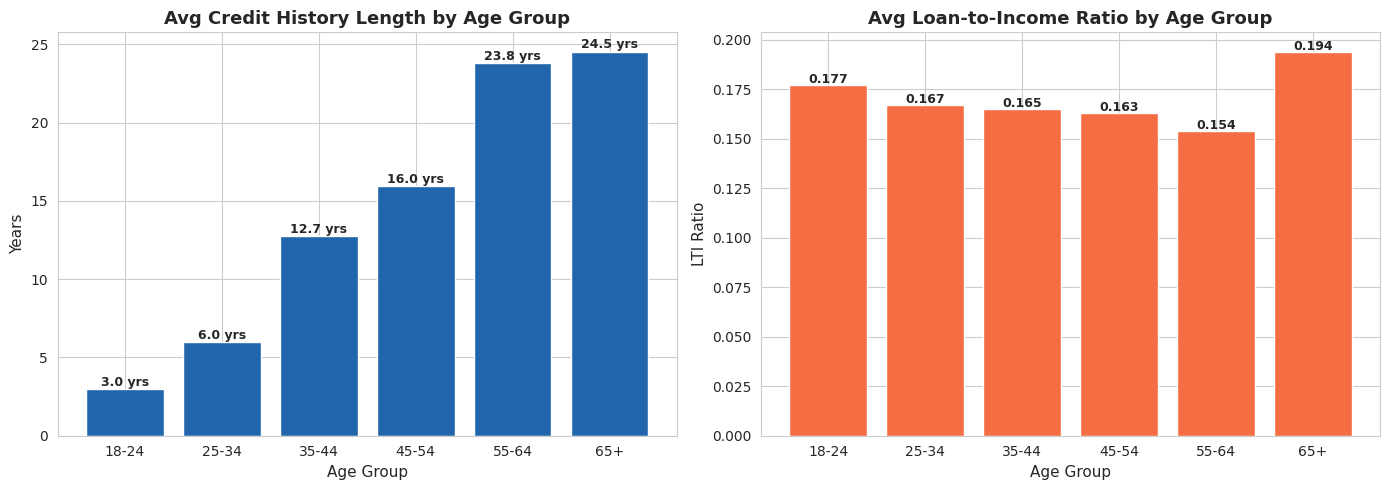

In [43]:
# === CREDIT HISTORY & LTI BY AGE ===
cred_eda = (
    df.groupby('age_group', observed=True)
    .agg(Avg_Credit_History_Yrs=('cb_person_cred_hist_length','mean'),
         Avg_LTI_Ratio=('loan_to_income_ratio','mean'),
         Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1),
            Avg_Credit_History_Yrs=lambda x: x['Avg_Credit_History_Yrs'].round(2),
            Avg_LTI_Ratio=lambda x: x['Avg_LTI_Ratio'].round(3))
    .reset_index()
)
print("CREDIT HISTORY & LTI RATIO BY AGE GROUP")
print(cred_eda.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(cred_eda['age_group'].astype(str), cred_eda['Avg_Credit_History_Yrs'],
            color=PALETTE['primary'], edgecolor='white')
for i, v in enumerate(cred_eda['Avg_Credit_History_Yrs']):
    axes[0].text(i, v + 0.2, f'{v:.1f} yrs', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Avg Credit History Length by Age Group')
axes[0].set_ylabel('Years')
axes[0].set_xlabel('Age Group')

axes[1].bar(cred_eda['age_group'].astype(str), cred_eda['Avg_LTI_Ratio'],
            color=PALETTE['warning'], edgecolor='white')
for i, v in enumerate(cred_eda['Avg_LTI_Ratio']):
    axes[1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Avg Loan-to-Income Ratio by Age Group')
axes[1].set_ylabel('LTI Ratio')
axes[1].set_xlabel('Age Group')
plt.tight_layout()
plt.show()

### 5.7 Home Ownership & Affordability

**Question:** Does housing status affect repayment capacity?

HOME OWNERSHIP — DEFAULT RATES & AFFORDABILITY RATIOS
person_home_ownership  Applications  Defaults  Avg_LTI  Avg_DTI  Default_Rate_pct
                 RENT         16446      5192    0.183    0.358            31.600
             MORTGAGE         13444      1690    0.152    0.327            12.600
                  OWN          2584       193    0.189    0.363             7.500
                OTHER           107        33    0.193    0.362            30.800


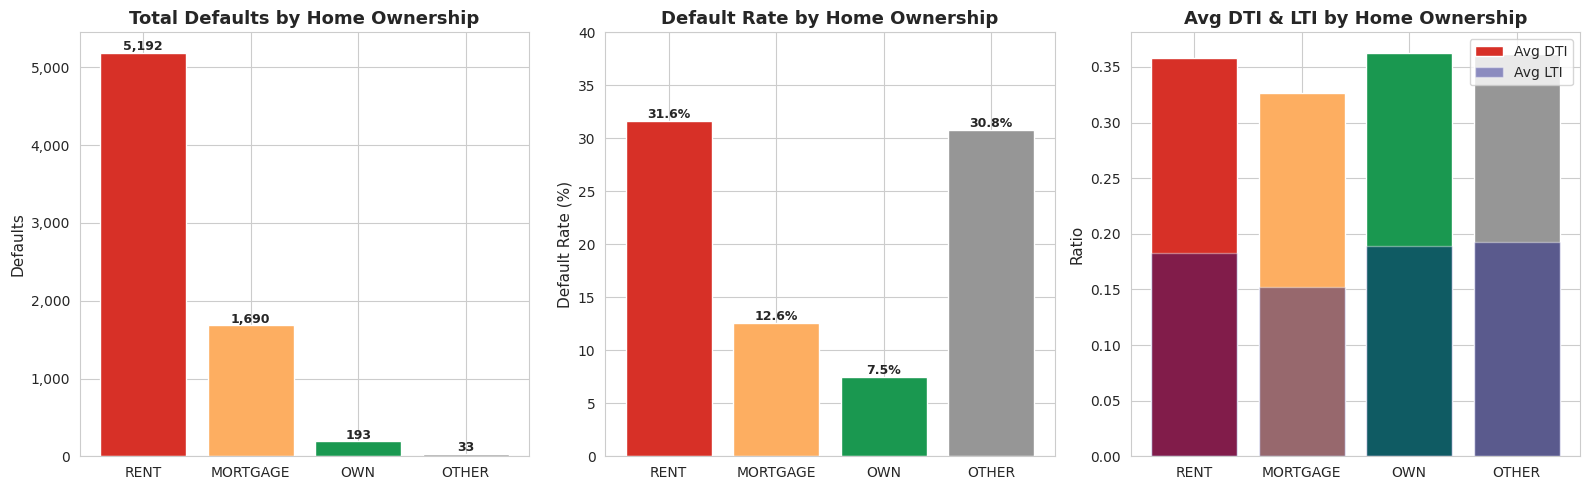

In [44]:
# === HOME OWNERSHIP ===
home_eda = (
    df.groupby('person_home_ownership')
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'),
         Avg_LTI=('loan_to_income_ratio','mean'), Avg_DTI=('debt_to_income_ratio','mean'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1),
            Avg_LTI=lambda x: x['Avg_LTI'].round(3),
            Avg_DTI=lambda x: x['Avg_DTI'].round(3))
    .sort_values('Defaults', ascending=False)
    .reset_index()
)
print("HOME OWNERSHIP — DEFAULT RATES & AFFORDABILITY RATIOS")
print(home_eda.to_string(index=False))

# Visualisation
home_color_map = {'RENT': PALETTE['danger'], 'MORTGAGE': PALETTE['highlight'],
                  'OWN': PALETTE['safe'], 'OTHER': PALETTE['neutral']}
hc = [home_color_map.get(h, PALETTE['neutral']) for h in home_eda['person_home_ownership']]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(home_eda['person_home_ownership'], home_eda['Defaults'], color=hc, edgecolor='white')
for i, v in enumerate(home_eda['Defaults']):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Total Defaults by Home Ownership')
axes[0].set_ylabel('Defaults')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].bar(home_eda['person_home_ownership'], home_eda['Default_Rate_pct'], color=hc, edgecolor='white')
for i, v in enumerate(home_eda['Default_Rate_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Default Rate by Home Ownership')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, 40)

axes[2].bar(home_eda['person_home_ownership'], home_eda['Avg_DTI'],
            color=hc, edgecolor='white', label='Avg DTI')
axes[2].bar(home_eda['person_home_ownership'], home_eda['Avg_LTI'],
            color='navy', edgecolor='white', alpha=0.4, label='Avg LTI')
axes[2].set_title('Avg DTI & LTI by Home Ownership')
axes[2].set_ylabel('Ratio')
axes[2].legend()
plt.tight_layout()
plt.show()

### 5.8 Loan Amount Distribution

**Question:** Do larger loans carry higher default risk?

LOAN AMOUNT BANDS — DEFAULT RATES
loan_amnt_band  Applications  Defaults  Default_Rate_pct
         $0-4k          6194      1309            21.100
         $4-8k         10611      1849            17.400
        $8-12k          7606      1523            20.000
       $12-16k          3875      1016            26.200
       $16-20k          2155       667            31.000
       $20-26k          1712       601            35.100
         $26k+           428       143            33.400


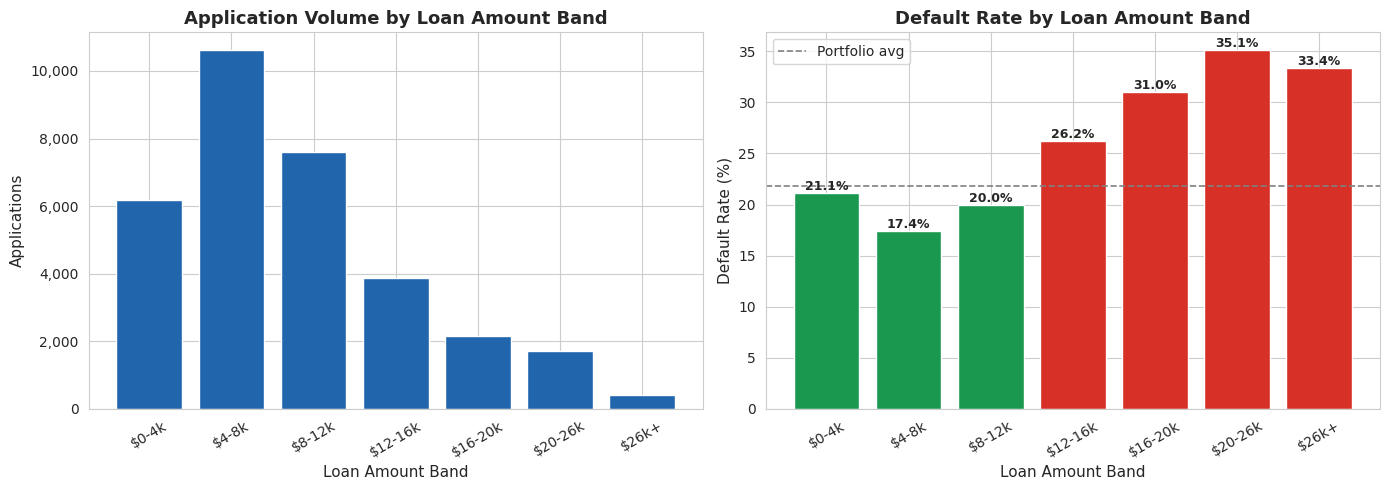

In [45]:
# === LOAN AMOUNT BANDS ===
amnt_eda = (
    df.groupby('loan_amnt_band', observed=True)
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("LOAN AMOUNT BANDS — DEFAULT RATES")
print(amnt_eda.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(amnt_eda['loan_amnt_band'].astype(str), amnt_eda['Applications'],
            color=PALETTE['primary'], edgecolor='white')
axes[0].set_title('Application Volume by Loan Amount Band')
axes[0].set_ylabel('Applications')
axes[0].set_xlabel('Loan Amount Band')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

bar_colors = [PALETTE['safe'] if r < df['loan_status'].mean()*100 else PALETTE['danger']
              for r in amnt_eda['Default_Rate_pct']]
axes[1].bar(amnt_eda['loan_amnt_band'].astype(str), amnt_eda['Default_Rate_pct'],
            color=bar_colors, edgecolor='white')
for i, v in enumerate(amnt_eda['Default_Rate_pct']):
    axes[1].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[1].axhline(y=df['loan_status'].mean()*100, color='gray', linestyle='--',
                linewidth=1.2, label='Portfolio avg')
axes[1].set_title('Default Rate by Loan Amount Band')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xlabel('Loan Amount Band')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
plt.tight_layout()
plt.show()

### 5.9 Loan Grade & Term Analysis

**Question:** Which loan grades and repayment terms are safest?

LOAN GRADE SUMMARY
loan_grade  Applications  Defaults  Default_Rate_pct
         A         10777      1073            10.000
         B         10451      1701            16.300
         C          6458      1339            20.700
         D          3626      2141            59.000
         E           964       621            64.400
         F           241       170            70.500
         G            64        63            98.400

LOAN GRADE x TERM — DEFAULT RATES
loan_grade  loan_term_months  Applications  Defaults  Default_Rate_pct
         A                12          1059        96             9.100
         A                24          2187       250            11.400
         A                36          4269       410             9.600
         A                60          3262       317             9.700
         B                12          1126       170            15.100
         B                24          1979       330            16.700
         B               

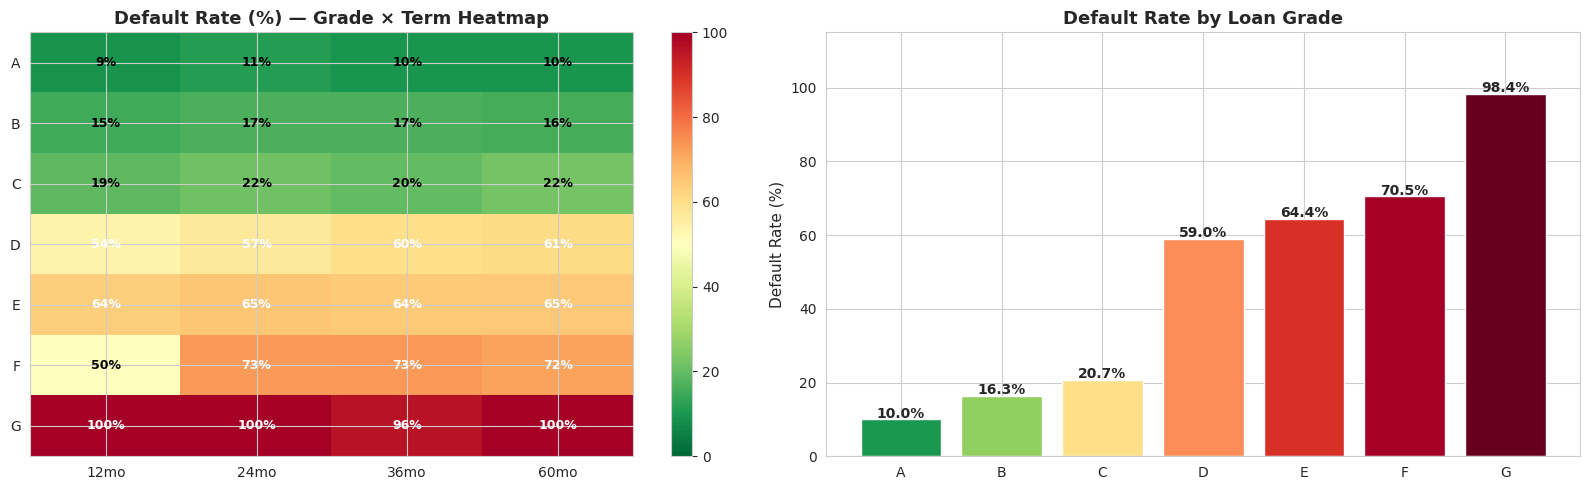

In [46]:
# === LOAN GRADE SUMMARY ===
grade_summary = (
    df.groupby('loan_grade')
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("LOAN GRADE SUMMARY")
print(grade_summary.to_string(index=False))

# === GRADE x TERM ===
print()
grade_term = (
    df.groupby(['loan_grade','loan_term_months'])
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1))
    .reset_index()
)
print("LOAN GRADE x TERM — DEFAULT RATES")
print(grade_term.to_string(index=False))

# Visualisation
pivot = grade_term.pivot(index='loan_grade', columns='loan_term_months', values='Default_Rate_pct')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im = axes[0].imshow(pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
axes[0].set_xticks(range(len(pivot.columns)))
axes[0].set_xticklabels([f'{c}mo' for c in pivot.columns])
axes[0].set_yticks(range(len(pivot.index)))
axes[0].set_yticklabels(pivot.index)
axes[0].set_title('Default Rate (%) — Grade × Term Heatmap')
plt.colorbar(im, ax=axes[0])
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i][j]
        axes[0].text(j, i, f'{val:.0f}%', ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color='white' if val > 50 else 'black')

gc = [GRADE_COLORS.get(g, 'gray') for g in grade_summary['loan_grade']]
bars = axes[1].bar(grade_summary['loan_grade'], grade_summary['Default_Rate_pct'],
                   color=gc, edgecolor='white')
for bar, v in zip(bars, grade_summary['Default_Rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Default Rate by Loan Grade')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, 115)
plt.tight_layout()
plt.show()

### 5.10 Account Behaviour & Delinquency

**Question:** Do open accounts and past delinquencies vary across age groups?

ACCOUNT BEHAVIOUR BY AGE GROUP
age_group  Applications  Defaults  Avg_Open_Accounts  Avg_Delinquencies  Avg_Credit_Util  Default_Rate_pct
    18-24         12315      2860              8.070              0.500            0.498            23.200
    25-34         16185      3393              8.020              0.510            0.501            21.000
    35-44          3326       684              8.060              0.510            0.502            20.600
    45-54           601       132              8.040              0.520            0.485            22.000
    55-64           115        31              7.650              0.370            0.544            27.000
      65+            39         8              8.150              0.540            0.603            20.500


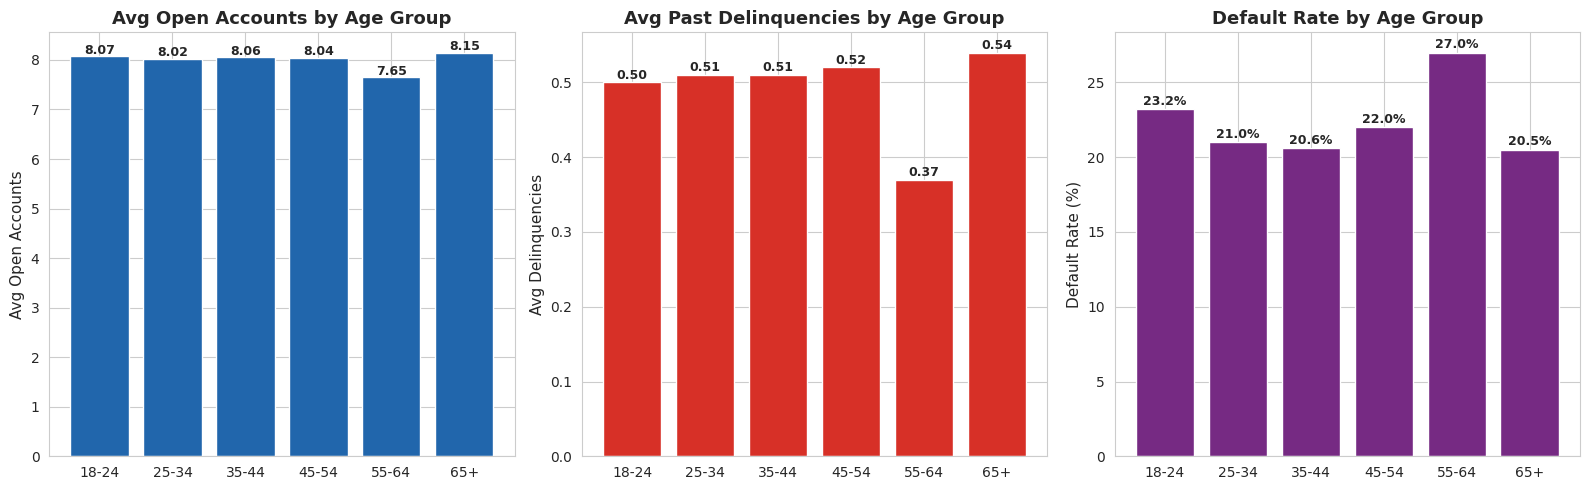

In [47]:
# === ACCOUNT BEHAVIOUR ===
acct_eda = (
    df.groupby('age_group', observed=True)
    .agg(Applications=('loan_status','count'), Defaults=('loan_status','sum'),
         Avg_Open_Accounts=('open_accounts','mean'),
         Avg_Delinquencies=('past_delinquencies','mean'),
         Avg_Credit_Util=('credit_utilization_ratio','mean'))
    .assign(Default_Rate_pct=lambda x: (x['Defaults']/x['Applications']*100).round(1),
            Avg_Open_Accounts=lambda x: x['Avg_Open_Accounts'].round(2),
            Avg_Delinquencies=lambda x: x['Avg_Delinquencies'].round(2),
            Avg_Credit_Util=lambda x: x['Avg_Credit_Util'].round(3))
    .reset_index()
)
print("ACCOUNT BEHAVIOUR BY AGE GROUP")
print(acct_eda.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(acct_eda['age_group'].astype(str), acct_eda['Avg_Open_Accounts'],
            color=PALETTE['primary'], edgecolor='white')
for i, v in enumerate(acct_eda['Avg_Open_Accounts']):
    axes[0].text(i, v + 0.05, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Avg Open Accounts by Age Group')
axes[0].set_ylabel('Avg Open Accounts')

axes[1].bar(acct_eda['age_group'].astype(str), acct_eda['Avg_Delinquencies'],
            color=PALETTE['danger'], edgecolor='white')
for i, v in enumerate(acct_eda['Avg_Delinquencies']):
    axes[1].text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Avg Past Delinquencies by Age Group')
axes[1].set_ylabel('Avg Delinquencies')

axes[2].bar(acct_eda['age_group'].astype(str), acct_eda['Default_Rate_pct'],
            color='#762a83', edgecolor='white')
for i, v in enumerate(acct_eda['Default_Rate_pct']):
    axes[2].text(i, v + 0.3, f'{v}%', ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Default Rate by Age Group')
axes[2].set_ylabel('Default Rate (%)')
plt.tight_layout()
plt.show()

### 5.11 Correlation Analysis

**Question:** Which numeric features are most correlated with each other — and what does that imply for modelling?

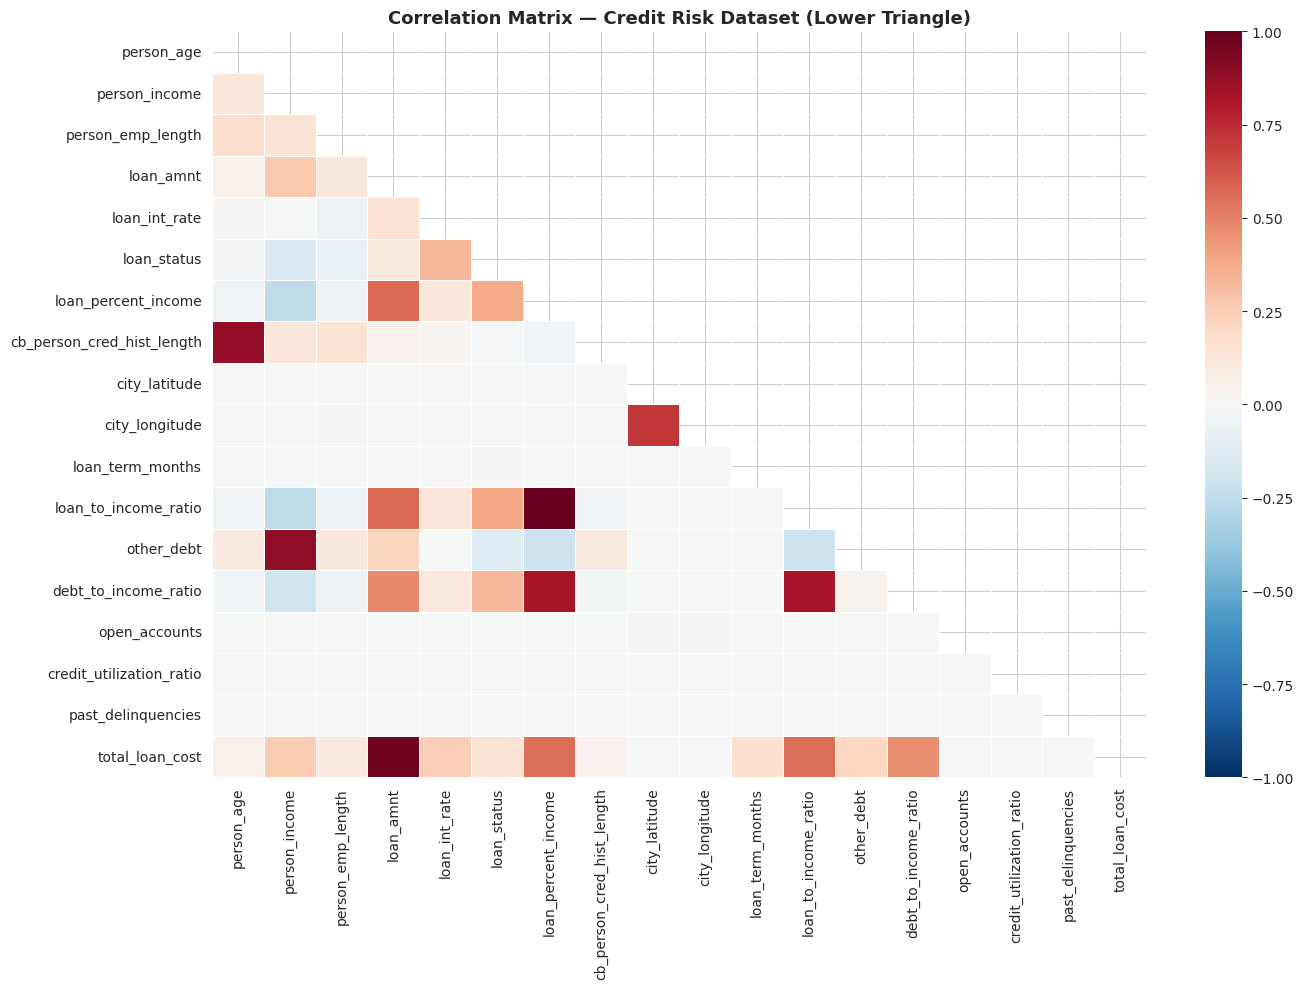

HIGHLY CORRELATED PAIRS (|r| ≥ 0.7)
            Feature1                   Feature2  Correlation  Abs_Corr
 loan_percent_income       loan_to_income_ratio        0.999     0.999
           loan_amnt            total_loan_cost        0.970     0.970
       person_income                 other_debt        0.887     0.887
          person_age cb_person_cred_hist_length        0.878     0.878
loan_to_income_ratio       debt_to_income_ratio        0.829     0.829
 loan_percent_income       debt_to_income_ratio        0.828     0.828
       city_latitude             city_longitude        0.714     0.714


In [48]:
# === CORRELATION MATRIX ===
num_df = df.select_dtypes(include=[np.number])
corr   = num_df.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, annot=False)
ax.set_title('Correlation Matrix — Credit Risk Dataset (Lower Triangle)')
plt.tight_layout()
plt.show()

# High correlation pairs
pairs = [(f1, f2, corr.loc[f1, f2])
         for f1, f2 in combinations(corr.columns, 2)]
pairs_df = (pd.DataFrame(pairs, columns=['Feature1','Feature2','Correlation'])
             .assign(Abs_Corr=lambda x: x['Correlation'].abs())
             .sort_values('Abs_Corr', ascending=False))

high = pairs_df[pairs_df['Abs_Corr'] >= 0.7]
print("HIGHLY CORRELATED PAIRS (|r| ≥ 0.7)")
print(high.to_string(index=False))

### 5.12 EDA Summary Table

In [49]:
# === CONSOLIDATED SUMMARY ===
print(f"{'='*60}")
print("EDA SUMMARY — DEFAULT RATES ACROSS ALL DIMENSIONS")
print(f"{'='*60}")

print("\n[1] BY LOAN INTENT")
print(intent_eda[['loan_intent','Default_Rate_pct']].to_string(index=False))

print("\n[2] BY COUNTRY")
print(country_eda[['country','Applications','Default_Rate_pct']].to_string(index=False))

print("\n[3] BY GENDER")
print(gender_eda[['gender','Applications','Default_Rate_pct']].to_string(index=False))

print("\n[4] BY AGE GROUP")
print(age_eda[['age_group','Applications','Default_Rate_pct']].to_string(index=False))

print("\n[5] BY EMPLOYMENT TENURE")
print(emp_eda[['emp_tenure_group','Default_Rate_pct','Median_Income']].to_string(index=False))

print("\n[6] BY HOME OWNERSHIP")
print(home_eda[['person_home_ownership','Defaults','Default_Rate_pct']].to_string(index=False))

print("\n[7] BY LOAN GRADE")
print(grade_summary[['loan_grade','Applications','Default_Rate_pct']].to_string(index=False))

print("\n[8] BY LOAN AMOUNT BAND")
print(amnt_eda[['loan_amnt_band','Applications','Default_Rate_pct']].to_string(index=False))

print(f"\n{'='*60}")
print(f"  Portfolio Overall Default Rate : {df['loan_status'].mean()*100:.1f}%")
print(f"  Total Applications             : {len(df):,}")
print(f"  Total Defaults                 : {df['loan_status'].sum():,}")
print(f"{'='*60}")

EDA SUMMARY — DEFAULT RATES ACROSS ALL DIMENSIONS

[1] BY LOAN INTENT
      loan_intent  Default_Rate_pct
DEBTCONSOLIDATION            28.600
          MEDICAL            26.700
  HOMEIMPROVEMENT            26.100
         PERSONAL            19.900
        EDUCATION            17.200
          VENTURE            14.800

[2] BY COUNTRY
country  Applications  Default_Rate_pct
 Canada         10785            21.900
     UK         10944            21.700
    USA         10852            21.900

[3] BY GENDER
gender  Applications  Default_Rate_pct
Female         16210            21.900
  Male         16371            21.800

[4] BY AGE GROUP
age_group  Applications  Default_Rate_pct
    18-24         12315            23.200
    25-34         16185            21.000
    35-44          3326            20.600
    45-54           601            22.000
    55-64           115            27.000
      65+            39            20.500

[5] BY EMPLOYMENT TENURE
emp_tenure_group  Default_Rate_p

---
## 6. Save Cleaned Dataset

Save the final analysis-ready dataset to Excel for use in Power BI. This file is the source for the Nova Bank dashboard.

In [ ]:
# === SAVE TO EXCEL ===
output_path = 'credit_cleaned.xlsx'
df.to_excel(output_path, index=False, sheet_name='Loan_Applications')

print(f"✅ Cleaned dataset saved to: {output_path}")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print()
print("New columns added vs raw dataset:")
original_cols = list(pd.read_excel('credit_risk.xlsx').columns)
new_cols = [c for c in df.columns if c not in original_cols]
for col in new_cols:
    print(f"  + {col}")

---
## 7. Notebook Summary

This notebook produced a clean, analysis-ready dataset and a full exploratory analysis of Nova Bank's lending portfolio.

### Data Cleaning
- Resolved **2 columns** with missing values: `loan_int_rate` (9.56%) and `person_emp_length` (2.75%)
- Corrected **5 biologically impossible ages** (>100) and **impossible employment lengths** (>60 years)
- All imputation used median values to preserve distribution integrity

### Feature Engineering
- Added **6 new columns**: `age_group`, `age_class`, `emp_tenure_group`, `total_loan_cost`, `loan_amnt_band`, `default_label`
- Final dataset: **32,581 rows × 35 columns**

### Key EDA Findings
| Finding | Detail |
|---|---|
| Overall default rate | 21.8% — 1 in 5 loans defaults |
| Riskiest loan intent | Debt Consolidation (28.6%) and Medical (26.7%) |
| Safest loan intent | Venture (14.8%) and Education (17.2%) |
| Geographic risk | Uniform at country level (~22%) — Vancouver, Dallas, Edinburgh are highest by city |
| Employment risk | 0-2 year tenure: 27.0% default vs 16-19 year tenure: 13.4% |
| Home ownership | Renters: 31.6% default rate vs Mortgage holders: 12.6% |
| Riskiest grade | Grade G: 98.4% default rate |
| Safest grade | Grade A: 10.0% default rate |

### Output File
`credit_cleaned.xlsx` — ready for import into Power BI for dashboard development.

---
*DataDNA September Challenge · Nova Bank Credit Risk Analytics*